<a href="https://colab.research.google.com/github/susmithadegala356-hash/battery-health-prediction/blob/main/file.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving battery_cycle_level_dataset_CLEAN_FINAL[1].csv to battery_cycle_level_dataset_CLEAN_FINAL[1] (1).csv


In [ ]:
import pandas as pd
df = pd.read_csv('battery_cycle_level_dataset_CLEAN_FINAL[1].csv')
df.head()

,battery_id,cycle,voltage,temperature,capacity,soh,rul
0,B0005,1,3.532781,32.536891,1.861976,1.000000,167
1,B0005,2,3.542968,32.643595,1.851862,0.994568,166
2,B0005,3,3.553056,32.522526,1.840808,0.988631,165
3,B0005,4,3.545849,32.492083,1.850058,0.993599,164
4,B0005,5,3.544456,32.368612,1.849432,0.993263,163


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1415 entries, 0 to 1414
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   battery_id   1415 non-null   object 
 1   cycle        1415 non-null   int64  
 2   voltage      1415 non-null   float64
 3   temperature  1415 non-null   float64
 4   capacity     1415 non-null   float64
 5   soh          1415 non-null   float64
 6   rul          1415 non-null   int64  
dtypes: float64(4), int64(2), object(1)
memory usage: 77.5+ KB


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
x=df[['cycle','voltage','temperature','capacity']]
y=df['soh']
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)
model=RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(x_train, y_train)
print("Model Training Complete!")

Model Training Complete!


In [ ]:
from sklearn.metrics import mean_absolute_error,r2_score
y_pred = model.predict(x_test)
print("MSE:", mean_absolute_error(y_test, y_pred))
print("R2 Score:", r2_score(y_test, y_pred))

MSE: 0.008262797120088115
R2 Score: 0.9741605888400776


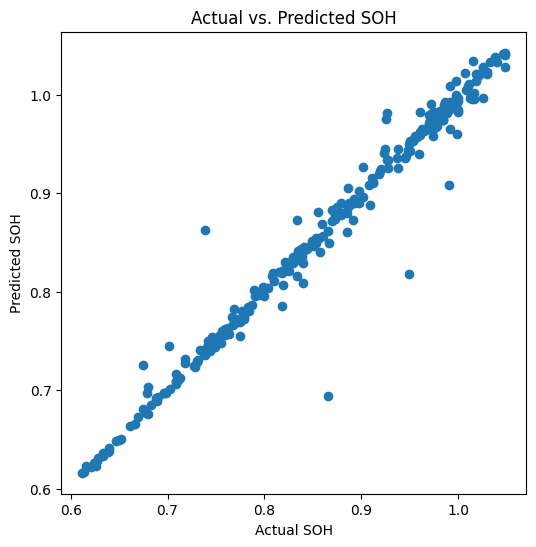

In [ ]:
import matplotlib.pyplot as plt
plt.figure(figsize=(6, 6))
plt.scatter(y_test, y_pred)
plt.xlabel('Actual SOH')
plt.ylabel('Predicted SOH')
plt.title('Actual vs. Predicted SOH')
plt.show()


In [ ]:
sample = [[100,3.5,32.0,1.8]]
prediction =model.predict(sample)
print("predicted SOH:",prediction[0])

predicted SOH: 0.8305466992190644


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(
